--------------------------

## Anode & Cathode Currents as a Function of Time in Comparison to Target Current (From C-Rate)
#### The example code below extracts and plots the currents from a full-cell simulation.

- Ensure the simulation output file (e.g., `full_cell_output.txt`) contains lines with `Anode current = ...` and `Cathode current = ...` values in a consistent format.
- Update the file path on Line #7 to point to the desired simulation output file.
- Modify Line #15 if extracting different variables or changing the parsing format.
- Change Line #27 to remove earlier timesteps.
- Run the script to generate a plot of cathode and anode currents versus time.

<p style="color:red;"><strong> Warning:</strong> Check that <code>full_cell_output.txt</code> only contains data from one simulation run. Reusing the file without clearing it can result in overlapping plot data.</p>

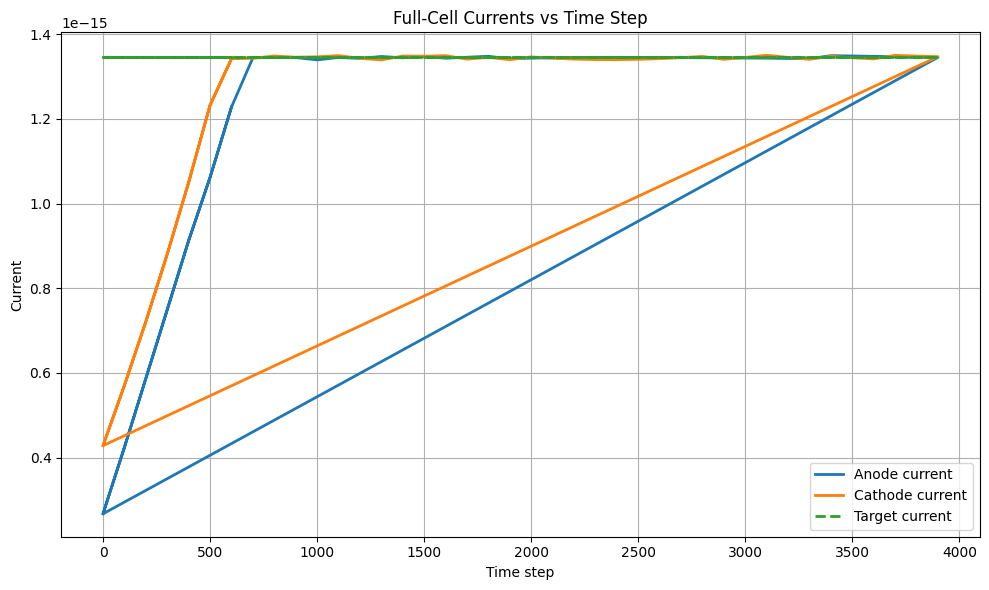

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"timestep:\s*(\d+).*?Anode current\s*=\s*([-eE0-9.]+),\s*Cathode current\s*=\s*([-eE0-9.]+),.*?Target Current\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        anode = abs(float(match.group(2)))  # absolute value
        cathode = float(match.group(3))
        target = float(match.group(4))
        data.append((timestep, anode, cathode, target))

# start_timestep = 0  # change this to a different timestep if needed

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["Timestep", "Anode", "Cathode", "Target"])
# df = df[df["Timestep"] >= start_timestep]

df = df[df["Timestep"] != 0] # Remove timestep 0

# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["Timestep"], df["Anode"], label="Anode current", linewidth=2)
plt.plot(df["Timestep"], df["Cathode"], label="Cathode current", linewidth=2)
plt.plot(df["Timestep"], df["Target"], '--', label="Target current", linewidth=2)

plt.xlabel("Time step")
plt.ylabel("Current")
plt.title("Full-Cell Currents vs Time Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--------------------------

## Cell Voltage Plots as a Function of Lithium Concentration
#### The example code below extracts and plots the cathode cell voltage from a full-cell simulation.

- Ensure the simulation output file (e.g., `full_cell_output.txt`) contains lines with `XfrC = ...` and `VCell = ...` values in a consistent format.
- Update the file path on Line #7 to point to the desired simulation output file.
- Modify Line #15 if extracting different variables or changing the parsing format.
- Run the script to generate a plot of cell voltage (`VCell`) versus cathode lithium fraction (`XfrC`).

<p style="color:red;"><strong> Warning:</strong> Check that <code>full_cell_output.txt</code> only contains data from one simulation run. Reusing the file without clearing it can result in overlapping plot data.</p>

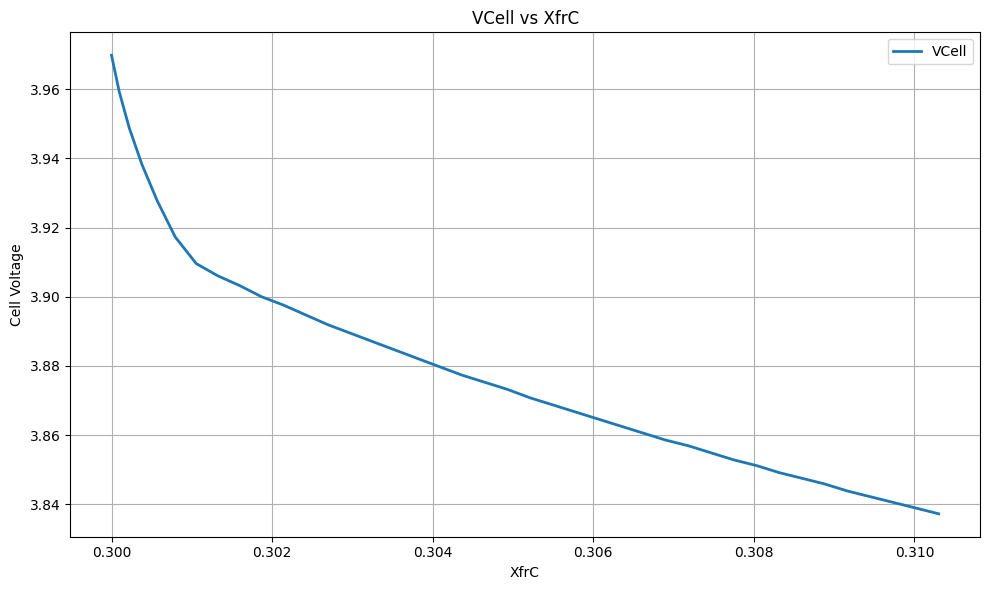

In [8]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Load text file ---
# Replace with your actual file name
file_path = "../bin/full_cell_output.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()

# --- Step 2: Parse each line using regex ---
data = []
pattern = re.compile(
    r"XfrC\s*=\s*([-eE0-9.]+),.*?VCell\s*=\s*([-eE0-9.]+)"
)

for line in lines:
    match = pattern.search(line)
    if match:
        XfrC = float(match.group(1))
        vcell = abs(float(match.group(2)))  # absolute value
        data.append((XfrC, vcell))

# --- Step 3: Convert to DataFrame ---
df = pd.DataFrame(data, columns=["XfrC", "VCell"])

# df = df[df["XfrC"] != 0.3] # Remove timestep 0


# --- Step 4: Plot ---
plt.figure(figsize=(10,6))
plt.plot(df["XfrC"], df["VCell"], label="VCell", linewidth=2)

plt.xlabel("XfrC")
plt.ylabel("Cell Voltage")
plt.title("VCell vs XfrC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
